Варіант 4 — Харків
     місто  місяць  температура  вологість  опалювальні_дні  \
0   Харків       1         -5.7       70.3               30   
1   Харків       2         -2.7       69.8               30   
2   Харків       3          2.9       74.8               30   
3   Харків       4          9.3       68.7               15   
4   Харків       5         16.5       61.4                0   
5   Харків       6         21.2       65.9                0   
6   Харків       7         22.9       63.9                0   
7   Харків       8         21.6       71.3                0   
8   Харків       9         15.8       71.6                0   
9   Харків      10          9.2       68.0               15   
10  Харків      11          0.7       80.3               30   
11  Харків      12         -5.2       75.1               30   

    витрати_на_опалення  
0                 378.2  
1                 337.4  
2                 286.9  
3                 187.6  
4                  62.1  
5    

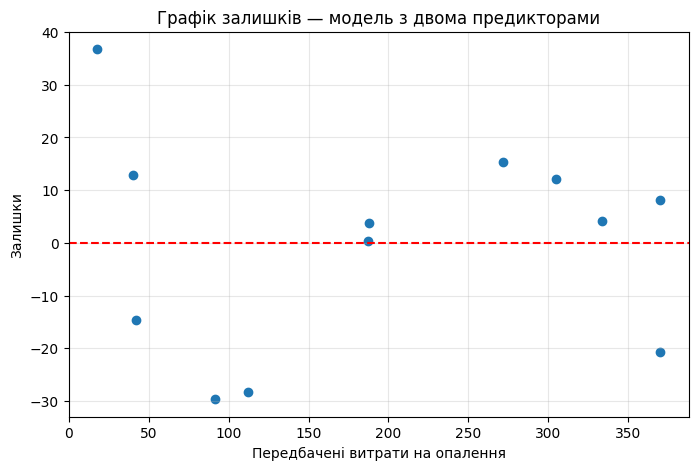

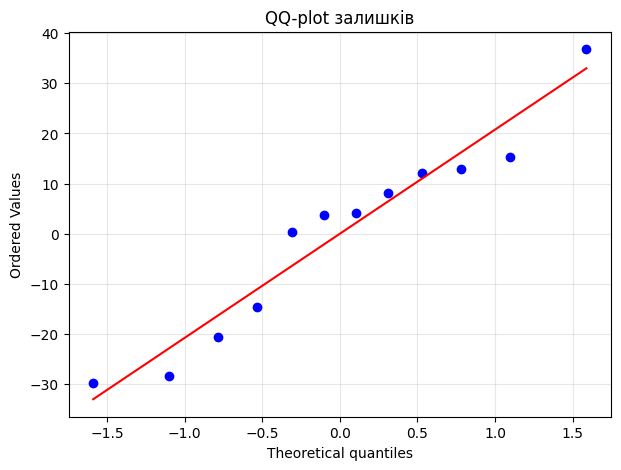


Критерій Шапіро-Вілка:
Статистика W = 0.9400
p-value = 0.4978
p-value >= 0.05 → немає підстав відхиляти H0. Дані не суперечать нормальності залишків.

Кореляція між передбаченими значеннями та залишками: 0.000000

ЗАВДАННЯ 6 — ПОРІВНЯННЯ З ПРОСТОЮ РЕГРЕСІЄЮ
                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.977
Model:                             OLS   Adj. R-squared:                  0.975
Method:                  Least Squares   F-statistic:                     424.1
Date:                 Wed, 30 Sep 2026   Prob (F-statistic):           1.61e-09
Time:                         06:50:25   Log-Likelihood:                -52.697
No. Observations:                   12   AIC:                             109.4
Df Residuals:                       10   BIC:                             110.4
Df Model:                            1                                         
Covariance Type:     

In [1]:
# ============================================
# ПРАКТИКА 18
# Множинна лінійна регресія
# Варіант 4 — Харків
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================
# ВАРІАНТ 4 — ХАРКІВ
# ============================================

np.random.seed(42)

city = "Харків"
mean_temp = 8.8
amplitude = 15
hum_base = 71

# ============================================
# ПОБУДОВА НАБОРУ ДАНИХ
# ============================================

rows = []

for month in range(1, 13):
    temp = (
        mean_temp
        + amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
        + np.random.normal(0, 1.0)
    )

    humidity = hum_base + np.random.normal(0, 5.0)

    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1)
    })

heating = pd.DataFrame(rows)

print("Варіант 4 — Харків")
print(heating)


# ============================================
# ЗАВДАННЯ 1
# Модель з двома предикторами
# витрати ~ температура + вологість
# ============================================

X = heating[["температура", "вологість"]]
X = sm.add_constant(X)

y = heating["витрати_на_опалення"]

model = sm.OLS(y, X).fit()

print("\n============================================")
print("ЗАВДАННЯ 1 — МОДЕЛЬ З ДВОМА ПРЕДИКТОРАМИ")
print("============================================")

print(model.summary())

print("\nR² =", round(model.rsquared, 4))
print("Adjusted R² =", round(model.rsquared_adj, 4))


# ============================================
# ЗАВДАННЯ 2
# Інтерпретація коефіцієнтів
# ============================================

print("\n============================================")
print("ЗАВДАННЯ 2 — КОЕФІЦІЄНТИ")
print("============================================")

coef = model.params
pvalues = model.pvalues

print("\nКоефіцієнти:")
print(coef)

print("\np-value:")
print(pvalues)

b0 = coef["const"]
b_temp = coef["температура"]
b_hum = coef["вологість"]

p_temp = pvalues["температура"]
p_hum = pvalues["вологість"]

print("\nРівняння моделі:")
print(
    f"витрати ≈ {b0:.3f} "
    f"+ ({b_temp:.3f}) × температура "
    f"+ ({b_hum:.3f}) × вологість"
)

print("\nІнтерпретація:")
print(
    f"За незмінної вологості підвищення температури на 1°C "
    f"пов'язане зі зміною витрат на {b_temp:.3f} умовних одиниць."
)

print(
    f"За незмінної температури підвищення вологості на 1 п.п. "
    f"пов'язане зі зміною витрат на {b_hum:.3f} умовних одиниць."
)

if p_temp < 0.05:
    print(
        f"Температура статистично значуща (p={p_temp:.4f} < 0.05)."
    )
else:
    print(
        f"Температура статистично незначуща (p={p_temp:.4f} >= 0.05)."
    )

if p_hum < 0.05:
    print(
        f"Вологість статистично значуща (p={p_hum:.4f} < 0.05)."
    )
else:
    print(
        f"Вологість статистично незначуща (p={p_hum:.4f} >= 0.05)."
    )


# ============================================
# ЗАВДАННЯ 3
# VIF
# ============================================

print("\n============================================")
print("ЗАВДАННЯ 3 — VIF")
print("============================================")

vif_table = pd.DataFrame()

vif_table["Предиктор"] = X.columns
vif_table["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_table)

print("\nVIF без константи:")

for i, column in enumerate(X.columns):
    if column != "const":
        vif = variance_inflation_factor(X.values, i)

        print(f"{column}: VIF = {vif:.3f}")

        if vif > 10:
            print("  -> серйозна мультиколінеарність")
        elif vif > 5:
            print("  -> варто звернути увагу на мультиколінеарність")
        else:
            print("  -> проблемної мультиколінеарності не виявлено")


# ============================================
# ЗАВДАННЯ 4
# Додаємо третій предиктор
# ============================================

print("\n============================================")
print("ЗАВДАННЯ 4 — ТРИ ПРЕДИКТОРИ")
print("============================================")

X3 = heating[
    ["температура", "вологість", "опалювальні_дні"]
]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

print("\nПорівняння моделей:")

comparison = pd.DataFrame({
    "Модель": [
        "Температура + вологість",
        "Температура + вологість + опалювальні_дні"
    ],
    "R²": [
        model.rsquared,
        model3.rsquared
    ],
    "Adjusted R²": [
        model.rsquared_adj,
        model3.rsquared_adj
    ]
})

print(comparison)

print("\nЗміна R²:",
      round(model3.rsquared - model.rsquared, 4))

print("Зміна Adjusted R²:",
      round(model3.rsquared_adj - model.rsquared_adj, 4))


# VIF для трьох предикторів

print("\nVIF для моделі з трьома предикторами:")

vif3 = pd.DataFrame()
vif3["Предиктор"] = X3.columns
vif3["VIF"] = [
    variance_inflation_factor(X3.values, i)
    for i in range(X3.shape[1])
]

print(vif3)


# ============================================
# ЗАВДАННЯ 5
# Діагностика залишків
# ============================================

print("\n============================================")
print("ЗАВДАННЯ 5 — ДІАГНОСТИКА ЗАЛИШКІВ")
print("============================================")

fitted = model.fittedvalues
residuals = model.resid

print("\nПередбачені значення:")
print(fitted.round(3))

print("\nЗалишки:")
print(residuals.round(3))

# --------------------------------------------
# Графік залишків проти передбачених значень
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(fitted, residuals)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Передбачені витрати на опалення")
plt.ylabel("Залишки")
plt.title("Графік залишків — модель з двома предикторами")

plt.grid(alpha=0.3)
plt.show()


# --------------------------------------------
# QQ-plot
# --------------------------------------------

plt.figure(figsize=(7, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ-plot залишків")
plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------
# Критерій Шапіро-Вілка
# --------------------------------------------

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("\nКритерій Шапіро-Вілка:")
print(f"Статистика W = {shapiro_stat:.4f}")
print(f"p-value = {shapiro_p:.4f}")

if shapiro_p < 0.05:
    print(
        "p-value < 0.05 → відхиляємо H0. "
        "Нормальність залишків статистично не підтверджується."
    )
else:
    print(
        "p-value >= 0.05 → немає підстав відхиляти H0. "
        "Дані не суперечать нормальності залишків."
    )


# ============================================
# ДОДАТКОВА ПЕРЕВІРКА
# Кореляція залишків із fitted values
# ============================================

res_fitted_corr = np.corrcoef(
    fitted,
    residuals
)[0, 1]

print(
    f"\nКореляція між передбаченими значеннями "
    f"та залишками: {res_fitted_corr:.6f}"
)


# ============================================
# ЗАВДАННЯ 6
# Порівняння з простою регресією
# Практика 17
# ============================================

print("\n============================================")
print("ЗАВДАННЯ 6 — ПОРІВНЯННЯ З ПРОСТОЮ РЕГРЕСІЄЮ")
print("============================================")

X_simple = sm.add_constant(
    heating[["температура"]]
)

simple_model = sm.OLS(
    y,
    X_simple
).fit()

print(simple_model.summary())

print("\nR² простої регресії:")
print(round(simple_model.rsquared, 4))

print("\nR² множинної регресії:")
print(round(model.rsquared, 4))

print("\nAdjusted R² множинної регресії:")
print(round(model.rsquared_adj, 4))

print("\nЗміна поясненої частки дисперсії:")
print(
    round(
        model.rsquared - simple_model.rsquared,
        4
    )
)


# ============================================
# ЗАГАЛЬНИЙ ВИСНОВОК
# ============================================

print("\n============================================")
print("ЗАГАЛЬНИЙ ВИСНОВОК")
print("============================================")

print(
    f"Для Харкова модель з температурою та вологістю "
    f"має R² = {model.rsquared:.3f} "
    f"та adjusted R² = {model.rsquared_adj:.3f}."
)

print(
    f"Після додавання опалювальних днів "
    f"R² = {model3.rsquared:.3f}, "
    f"adjusted R² = {model3.rsquared_adj:.3f}."
)

if model3.rsquared_adj > model.rsquared_adj:
    print(
        "Додавання опалювальних днів покращило adjusted R², "
        "тобто додатковий предиктор виправдав ускладнення моделі."
    )
else:
    print(
        "Додавання опалювальних днів не покращило adjusted R², "
        "тому його додавання не дає достатньої переваги за цим критерієм."
    )


1. Чому sm.add_constant() обов'язковий?

sm.add_constant() додає до матриці предикторів стовпець одиниць, завдяки якому модель оцінює вільний член b0. Без цього модель фактично не мала б окремого перетину з віссю Y і регресійна модель була б змушена проходити через початок координат. Тому для стандартної лінійної регресії з intercept використання sm.add_constant() є необхідним.

2. Чим коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії?

У простій регресії коефіцієнт показує зв'язок між Y та одним предиктором без урахування інших змінних. У множинній регресії коефіцієнт показує зміну Y при зміні конкретного предиктора на одну одиницю за умови, що інші предиктори залишаються незмінними. Тому коефіцієнт множинної регресії має інтерпретацію "за інших рівних умов".

3. Чому R² не може зменшитися при додаванні нового предиктора?

Метод найменших квадратів при додаванні нового предиктора отримує додаткову можливість підлаштувати модель під дані. Навіть якщо новий предиктор взагалі не корисний, модель може залишити його коефіцієнт близьким до нуля і не погіршити суму квадратів залишків. Тому звичайний R² не зменшується. Саме тому для порівняння моделей із різною кількістю предикторів корисно використовувати adjusted R², який штрафує модель за додавання зайвих предикторів.

4. Що означає VIF ≈ 1 і VIF > 10?

VIF приблизно дорівнює 1, якщо предиктор практично не пояснюється іншими предикторами, тобто мультиколінеарність відсутня або дуже слабка. VIF понад 10 вказує на серйозну мультиколінеарність: предиктор сильно пов'язаний з іншими змінними моделі. У такій ситуації оцінки коефіцієнтів можуть бути нестабільними, а стандартні помилки — великими. На практиці варто перевірити пов'язані предиктори й розглянути, чи потрібно залишати їх разом у моделі.
